In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [7]:
X = np.arange(-200, 200, 5)
y = X + 10

In [8]:
s = len(X)
test_size = 0.2
amt = int(s * test_size)

amt

16

In [9]:
len(X)

80

In [10]:
X_train = X[:-amt]
y_train = y[:-amt]

X_test = X[-amt:]
y_test = y[-amt:]

len(X_train), len(X_test)

(64, 16)

In [11]:
len(X_train)

64

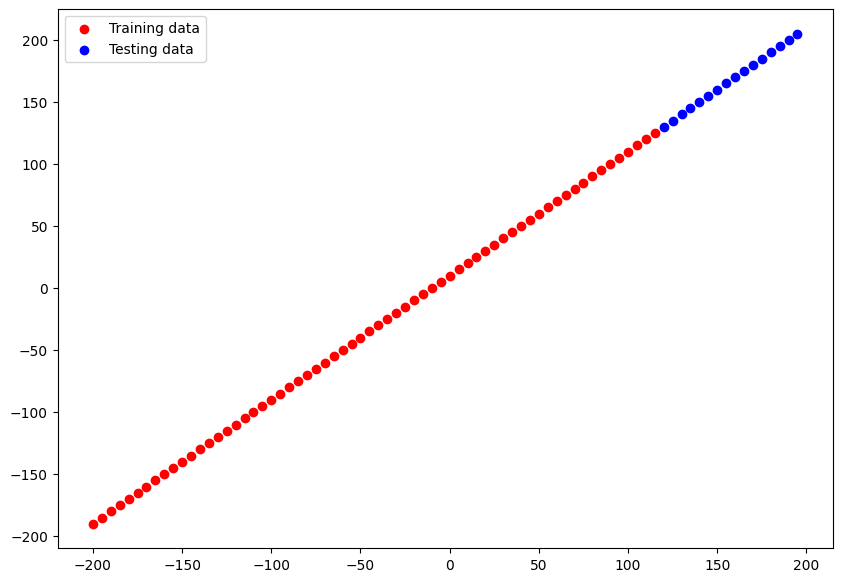

In [12]:
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="r", label="Training data")
plt.scatter(X_test, y_test, c="b", label="Testing data")
plt.legend()
plt.show()

In [13]:
base_model = tf.keras.Sequential([
  tf.keras.layers.Dense(1)
])

base_model.compile(loss=tf.keras.losses.mae,
                   optimizer=tf.keras.optimizers.SGD(),
                   metrics=["mae"])

loss_base_model = base_model.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)



Epoch 1/100
2/2 [==============================] - 1s 17ms/step - loss: 36.5875 - mae: 36.5875
Epoch 2/100
2/2 [==============================] - 0s 7ms/step - loss: 33.2270 - mae: 33.2270
Epoch 3/100
2/2 [==============================] - 0s 8ms/step - loss: 21.7522 - mae: 21.7522
Epoch 4/100
2/2 [==============================] - 0s 8ms/step - loss: 40.3838 - mae: 40.3838
Epoch 5/100
2/2 [==============================] - 0s 8ms/step - loss: 33.0458 - mae: 33.0458
Epoch 6/100
2/2 [==============================] - 0s 7ms/step - loss: 41.0752 - mae: 41.0752
Epoch 7/100
2/2 [==============================] - 0s 6ms/step - loss: 32.8363 - mae: 32.8363
Epoch 8/100
2/2 [==============================] - 0s 11ms/step - loss: 36.1824 - mae: 36.1824
Epoch 9/100
2/2 [==============================] - 0s 8ms/step - loss: 37.6716 - mae: 37.6716
Epoch 10/100
2/2 [==============================] - 0s 6ms/step - loss: 34.6433 - mae: 34.6433
Epoch 11/100
2/2 [==============================] - 0s 6m

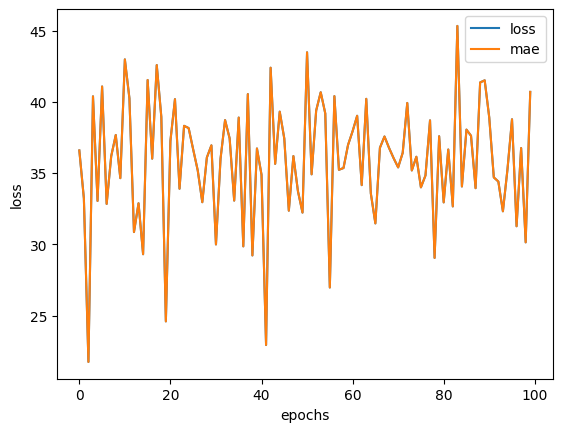

In [14]:
pd.DataFrame(loss_base_model.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.show()

In [15]:
base_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (32, 1)                   2         
                                                                 
Total params: 2 (8.00 Byte)
Trainable params: 2 (8.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


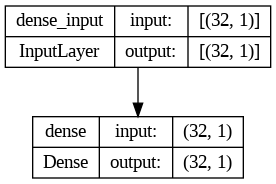

In [16]:
from tensorflow.keras.utils import plot_model
plot_model(base_model, show_shapes=True)

In [17]:
y_preds = base_model.predict(X_test)


1/1 [==============================] - 0s 118ms/step


In [18]:
y_preds

array([[58.52489 ],
       [60.947956],
       [63.371025],
       [65.79409 ],
       [68.217155],
       [70.64023 ],
       [73.06329 ],
       [75.48637 ],
       [77.90943 ],
       [80.3325  ],
       [82.75557 ],
       [85.178635],
       [87.60171 ],
       [90.02477 ],
       [92.44784 ],
       [94.87091 ]], dtype=float32)

In [27]:
def plot_preds(X_train, y_train, X_test, y_test, y_preds):
  plt.figure(figsize=(10, 7))
  plt.scatter(X_train, y_train, c="r", label="Training data", alpha=0.5)
  plt.scatter(X_test, y_test, c="b", label="Testing data", alpha=0.5)

  plt.scatter(X_test, y_preds, c="g", label="Predictions")
  plt.legend()
  plt.show()

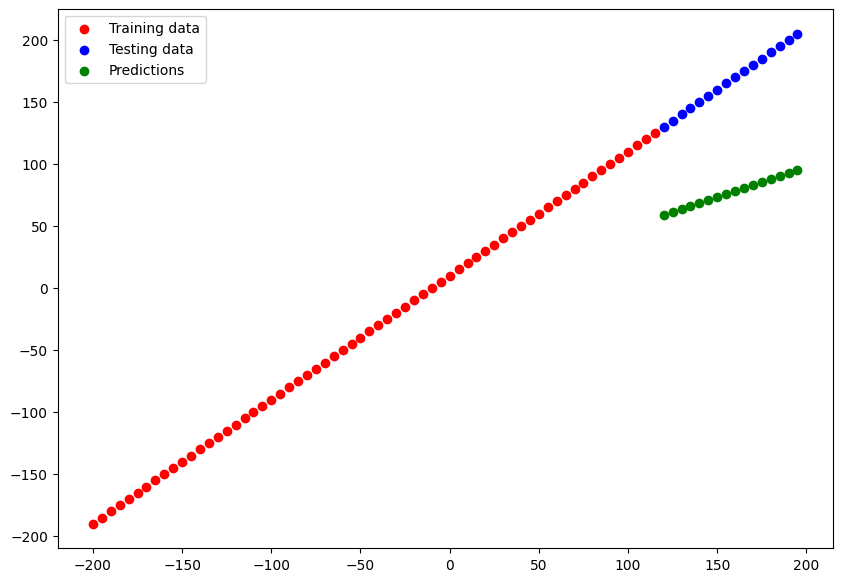

In [20]:
plot_preds(X_train, y_train, X_test, y_test, y_preds)

In [21]:
model_2 = tf.keras.Sequential([
  tf.keras.layers.Dense(1),
  tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.mae,
                   optimizer=tf.keras.optimizers.SGD(),
                   metrics=["mae"])

loss_model_2 = model_2.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=100)


Epoch 1/100
2/2 [==============================] - 1s 9ms/step - loss: 63.8686 - mae: 63.8686
Epoch 2/100
2/2 [==============================] - 0s 8ms/step - loss: 68.2100 - mae: 68.2100
Epoch 3/100
2/2 [==============================] - 0s 8ms/step - loss: 34.3091 - mae: 34.3091
Epoch 4/100
2/2 [==============================] - 0s 8ms/step - loss: 35.4722 - mae: 35.4722
Epoch 5/100
2/2 [==============================] - 0s 8ms/step - loss: 34.2067 - mae: 34.2067
Epoch 6/100
2/2 [==============================] - 0s 8ms/step - loss: 21.8823 - mae: 21.8823
Epoch 7/100
2/2 [==============================] - 0s 8ms/step - loss: 85.1560 - mae: 85.1560
Epoch 8/100
2/2 [==============================] - 0s 11ms/step - loss: 51.6581 - mae: 51.6581
Epoch 9/100
2/2 [==============================] - 0s 7ms/step - loss: 75.7180 - mae: 75.7180
Epoch 10/100
2/2 [==============================] - 0s 8ms/step - loss: 58.4878 - mae: 58.4878
Epoch 11/100
2/2 [==============================] - 0s 10m

In [22]:
y_preds_2 = model_2.predict(X_test)

1/1 [==============================] - 0s 129ms/step


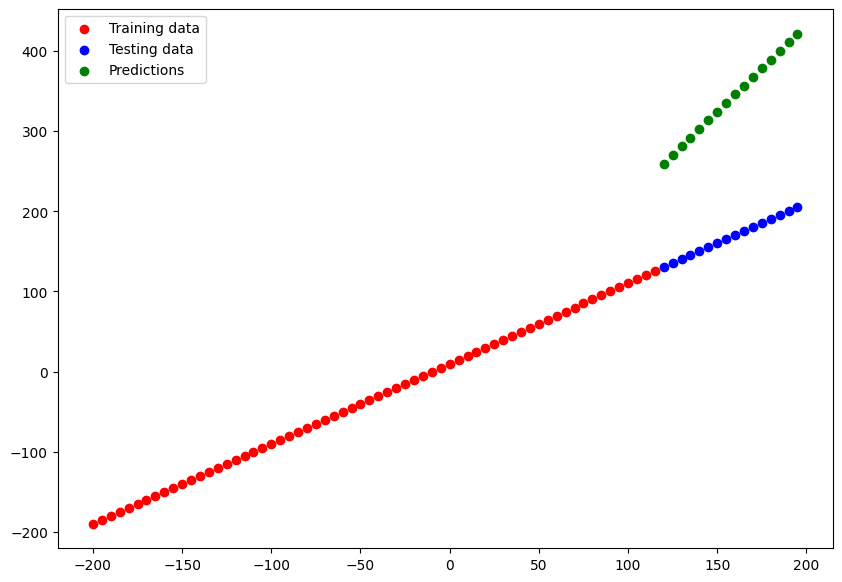

In [23]:
plot_preds(X_train, y_train, X_test, y_test, y_preds_2)

In [44]:
model_3 = tf.keras.Sequential([
  tf.keras.layers.Dense(10),
  tf.keras.layers.Dense(1)
])

model_3.compile(loss=tf.keras.losses.mae,
                   optimizer=tf.keras.optimizers.Adam(),
                   metrics=["mae"])

loss_model_3 = model_3.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=300,verbose=0)

1/1 [==============================] - 0s 81ms/step


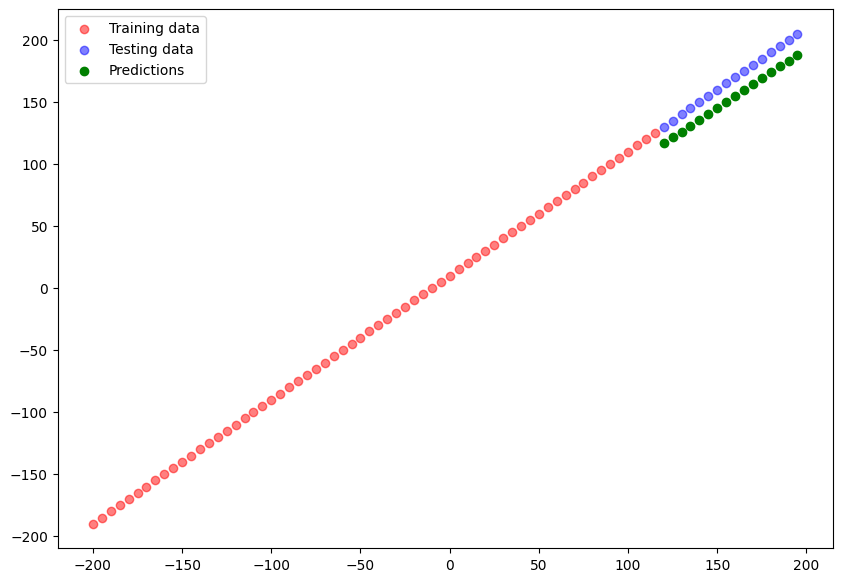

In [45]:
y_preds_3 = model_3.predict(X_test)
plot_preds(X_train, y_train, X_test, y_test, y_preds_3)

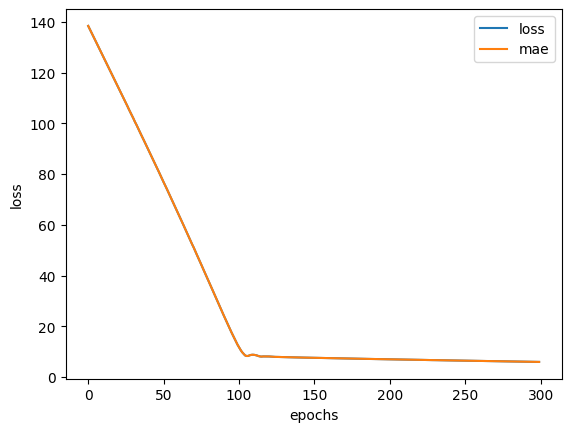

In [46]:
pd.DataFrame(loss_model_3.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.show()

In [47]:
model_3.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (32, 10)                  20        
                                                                 
 dense_19 (Dense)            (32, 1)                   11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [48]:
model_3.save("model_3.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [49]:
concrete = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/concrete.csv")

In [50]:
concrete.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [51]:
X = concrete.drop("strength", axis=1)
y = concrete["strength"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

In [53]:
X_train = np.array(X_train).astype("float32")
X_test = np.array(X_test).astype("float32")
y_train = np.array(y_train).astype("float32")
y_test = np.array(y_test).astype("float32")

In [54]:
concrete_base_model = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

concrete_base_model.compile(loss=tf.keras.losses.mae,
                            optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                            metrics=["mae"])

loss_concrete_base_model = concrete_base_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
26/26 [==============================] - 2s 3ms/step - loss: 151.6867 - mae: 151.6867
Epoch 2/100
26/26 [==============================] - 0s 3ms/step - loss: 17.7741 - mae: 17.7741
Epoch 3/100
26/26 [==============================] - 0s 3ms/step - loss: 15.9927 - mae: 15.9927
Epoch 4/100
26/26 [==============================] - 0s 3ms/step - loss: 10.4089 - mae: 10.4089
Epoch 5/100
26/26 [==============================] - 0s 3ms/step - loss: 10.0967 - mae: 10.0967
Epoch 6/100
26/26 [==============================] - 0s 3ms/step - loss: 12.5946 - mae: 12.5946
Epoch 7/100
26/26 [==============================] - 0s 3ms/step - loss: 16.5282 - mae: 16.5282
Epoch 8/100
26/26 [==============================] - 0s 3ms/step - loss: 13.3100 - mae: 13.3100
Epoch 9/100
26/26 [==============================] - 0s 3ms/step - loss: 11.9831 - mae: 11.9831
Epoch 10/100
26/26 [==============================] - 0s 3ms/step - loss: 10.2139 - mae: 10.2139
Epoch 11/100
26/26 [=================

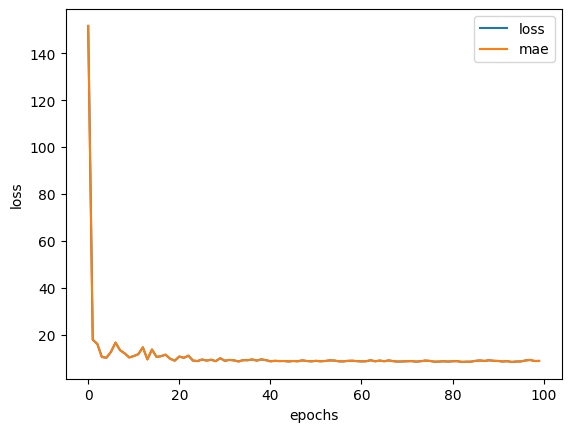

In [55]:
pd.DataFrame(loss_concrete_base_model.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")
plt.show()

In [56]:
concrete.columns

Index(['cement', 'slag', 'ash', 'water', 'superplastic', 'coarseagg',
       'fineagg', 'age', 'strength'],
      dtype='object')

In [57]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler


ct = make_column_transformer(
    (MinMaxScaler(), ["cement", "slag", "ash", "water", "superplastic", "coarseagg", "fineagg", "age"])
)

X = concrete.drop("strength", axis=1)
y = concrete["strength"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

ct.fit(X_train)

X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)


In [58]:
X_train_normal = np.array(X_train_normal).astype("float32")
X_test_normal = np.array(X_test_normal).astype("float32")
y_train = np.array(y_train).astype("float32")
y_test = np.array(y_test).astype("float32")

In [59]:
concrete_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1),
])

concrete_model_2.compile(loss=tf.keras.losses.mae,
                         optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                         metrics=["mae"])

loss_concrete_model_2 = concrete_model_2.fit(X_train_normal, y_train, epochs=100)

Epoch 1/100
26/26 [==============================] - 3s 5ms/step - loss: 20.6846 - mae: 20.6846
Epoch 2/100
26/26 [==============================] - 0s 5ms/step - loss: 10.9150 - mae: 10.9150
Epoch 3/100
26/26 [==============================] - 0s 5ms/step - loss: 9.2143 - mae: 9.2143
Epoch 4/100
26/26 [==============================] - 0s 6ms/step - loss: 8.6539 - mae: 8.6539
Epoch 5/100
26/26 [==============================] - 0s 5ms/step - loss: 8.4685 - mae: 8.4685
Epoch 6/100
26/26 [==============================] - 0s 5ms/step - loss: 8.5567 - mae: 8.5567
Epoch 7/100
26/26 [==============================] - 0s 5ms/step - loss: 8.8092 - mae: 8.8092
Epoch 8/100
26/26 [==============================] - 0s 5ms/step - loss: 8.4617 - mae: 8.4617
Epoch 9/100
26/26 [==============================] - 0s 5ms/step - loss: 8.9612 - mae: 8.9612
Epoch 10/100
26/26 [==============================] - 0s 5ms/step - loss: 8.4852 - mae: 8.4852
Epoch 11/100
26/26 [==============================] - 0